In [1]:
# We will be using stepwise subset to model our EDA
# First we will check our trimmed data for any null values
import pandas as pd
df = pd.read_csv("retail_inventory_2023_2024Trimmed.csv")

In [2]:
df.isna().sum()

Date                      0
Store ID                  0
Product ID                0
Category                  0
Region                    0
Inventory Level           0
Units Sold                0
Units Ordered             0
Demand Forecast           0
Price                     0
Discount                  0
Weather Condition         0
Holiday/Promotion         0
Competitor Pricing        0
Seasonality               0
Unnamed: 15           36600
Unnamed: 16           36600
dtype: int64

In [ ]:
# We have two columns that have no values in it and that are also unamed. Something in our preprocessing step messed up that format.
# We'll go ahead and drop those two columns now.

In [5]:
df = df.iloc[:, :-2]

In [6]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [ ]:
# Our dependent variable is Units Sold. We'll focus on that and observe EDA through bar graphs, boxplots, and scatterplots

In [ ]:
# We are going to see if the region, weather condition, and seasonality have a part to play with units sold

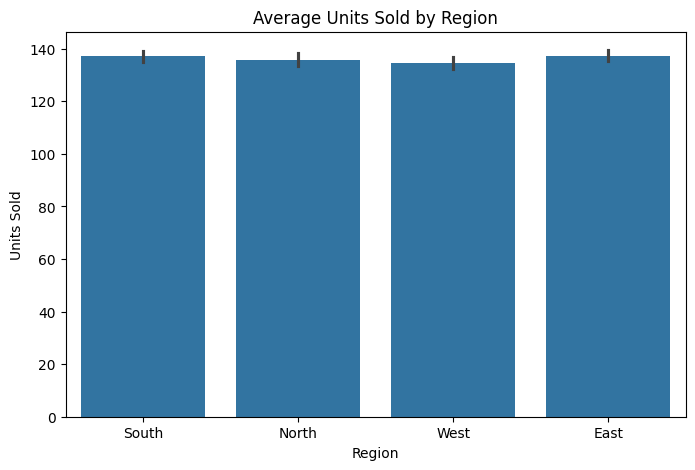

In [36]:
# Region
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Units Sold', data=df, estimator='mean')
plt.title('Average Units Sold by Region')
plt.show()

In [ ]:
# Weather Condition

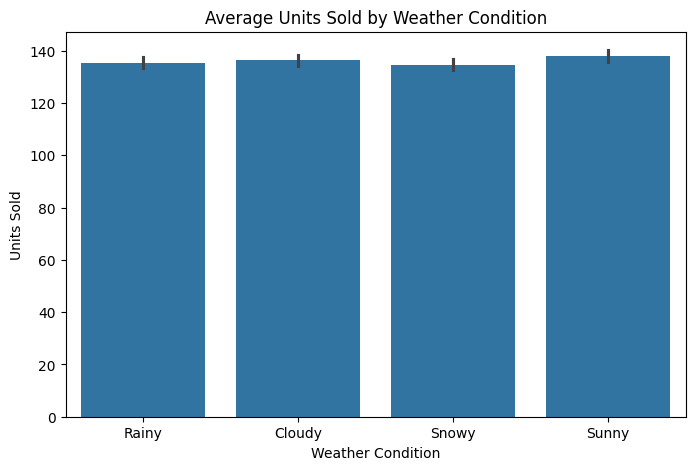

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(x='Weather Condition', y='Units Sold', data=df, estimator='mean')
plt.title('Average Units Sold by Weather Condition')
plt.show()

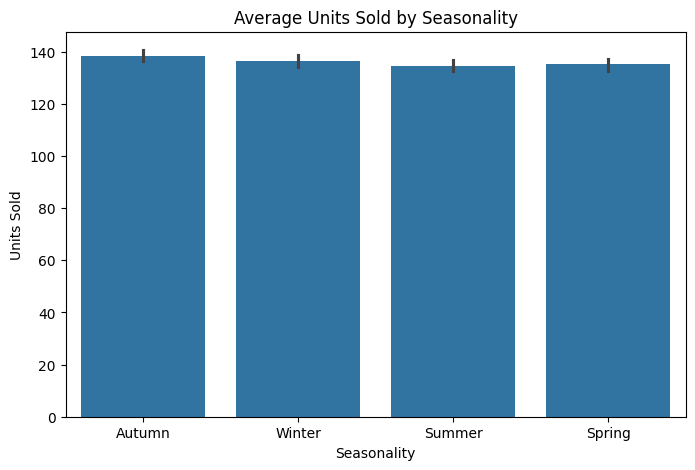

In [38]:
# Seasonality
plt.figure(figsize=(8,5))
sns.barplot(x='Seasonality', y='Units Sold', data=df, estimator='mean')
plt.title('Average Units Sold by Seasonality')
plt.show()

In [ ]:
# The region, weather, and season don't have an effect on units sold. Regardless of these conditions, customers will still
# go into the store and purchase items.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.head())
print(df.info())

         Date Store ID Product ID  Category Region  Inventory Level  \
0  2023-01-01     S001      P0001  Clothing  South              425   
1  2023-01-01     S001      P0002      Toys  North              240   
2  2023-01-01     S001      P0003  Clothing  North              330   
3  2023-01-01     S001      P0004  Clothing  North              383   
4  2023-01-01     S001      P0005      Toys  North              310   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         182             72           194.79  48.37        10   
1          91            135            99.06  69.97        20   
2         297             58           288.23  38.50        10   
3          10            166            26.69  31.03        10   
4          70            177            78.32  15.11         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  1               49.99      Autumn  
1            Cloudy           

In [ ]:
# Here we can see we have a couple of numerical and categorical values in this data set
# Some categories are related to each other, like weather condition and Seasonality.
# Going to start showing some visuals to help us determine what might be important to keep
# for our multiple linear regression

# There are also 36,600 recorded units sold in the year of 2023-2024. There were five stores in total with recorded data. Each store that recorded data
# for a certain day had different departments ranging from toys to clothing to furniture. Typical departments you'd find in a store

In [ ]:
# Now time to display some histograms to understand the distribution and skewness

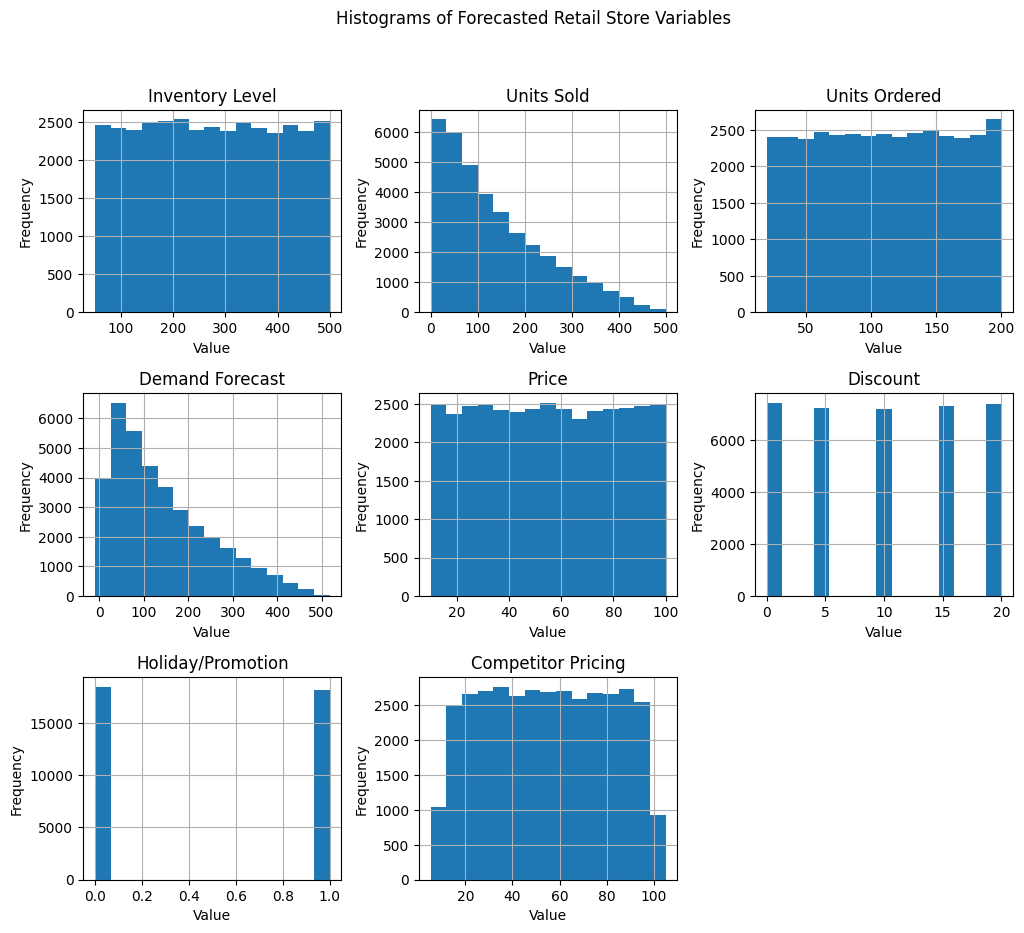

In [18]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
axes = df[numeric_cols].hist(figsize=(12,10), bins=15)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for ax in axes.flatten():
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
plt.suptitle("Histograms of Forecasted Retail Store Variables")
plt.show()

In [9]:
print(df[numeric_cols].skew())

Inventory Level       0.011593
Units Sold            0.900578
Units Ordered        -0.000461
Demand Forecast       0.891590
Price                 0.002817
Discount             -0.002700
Holiday/Promotion     0.017378
Competitor Pricing    0.001928
dtype: float64


In [ ]:
# The frequecy for units sold, our dependent variable, has a decreased trend going down. Overall this indicates the supply and demand
# theory of higher supply, less demand. The demand forecast backs up this theory for the most part too with the overall decrease trend as demand
# reaches its threshold. 
# Besides these two variables, we can see that the discount seems to be only in groups of 5% discounts. 5%, 10%, 15%, and 20%. The holiday/promotion 
# seems to be hot encoded. It's either a holiday/promotion or not.
# Only units ordered and discount are left skewed based on their negative skewness. The rest are right skewed. Visually speaking, it seems competitor
# pricing is the closest to being a nice bell shaped curve. Making it the closest to normal distribution

In [ ]:
# Boxplots to detect outliers and confirm skewness

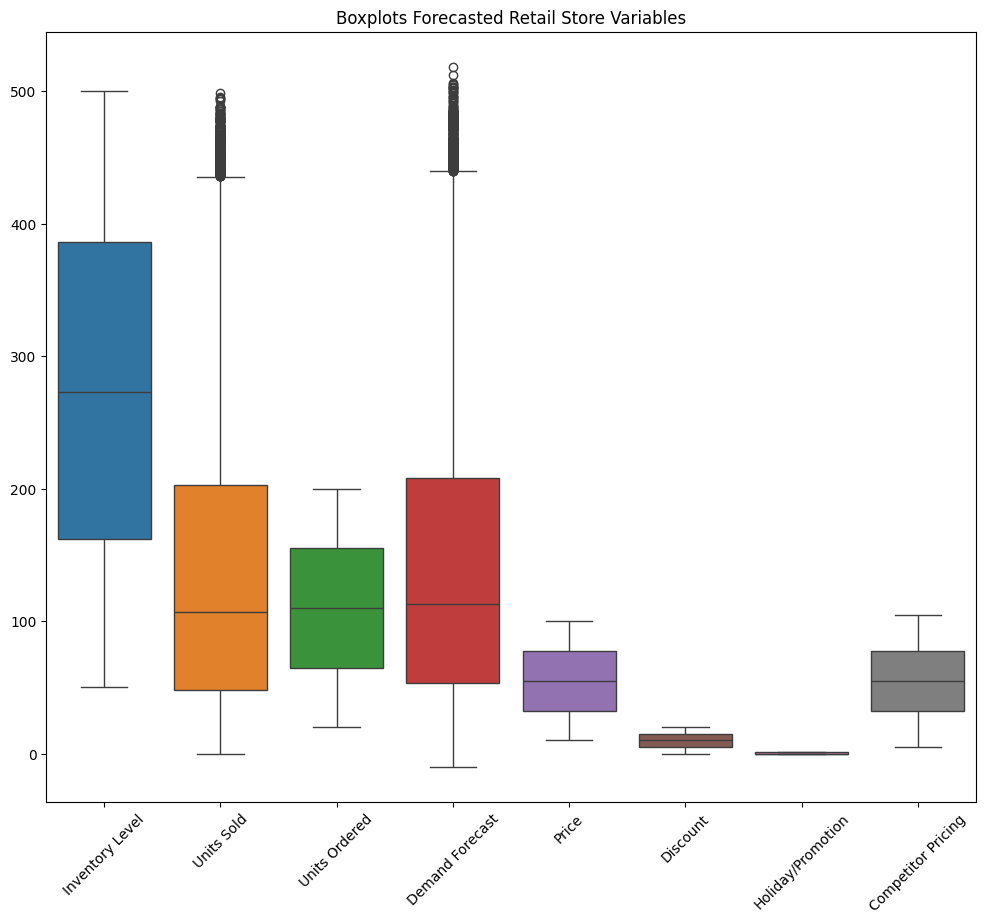

In [21]:
plt.figure(figsize=(12,10))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplots Forecasted Retail Store Variables')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# As we can see visually, units sold and demand forecast tend to have outliers while the rest don't
# This is due to the nature of supply and demand. What can attest for these reasons is the goal of our MLR predictions
# Demand spikes, out of stock inventory, and expired/long shelf life products cause these volatile issues.
# We wish to prevent stores from losing revenue or having too much inventory to prevent long shelf life,
# so the need for a good prediction is evident. 
# It's also quite interesting to see how the majority of variables right skewed visually. Since they are gravitating towards
# the bottom of the quartiles.

In [ ]:
# Now it's time to view the bar graphs via different stores. We want to analyze the mean of units sold in each store to see
# how the stores differ. We will also take into account how each product is sold as well

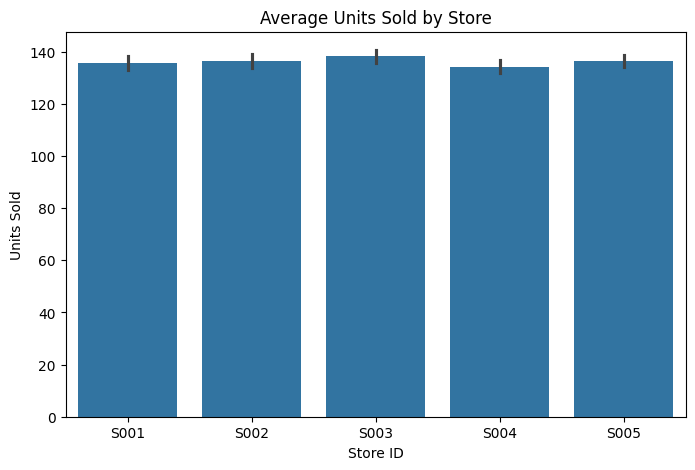

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x='Store ID', y='Units Sold', data=df, estimator='mean')
plt.title('Average Units Sold by Store')
plt.show()

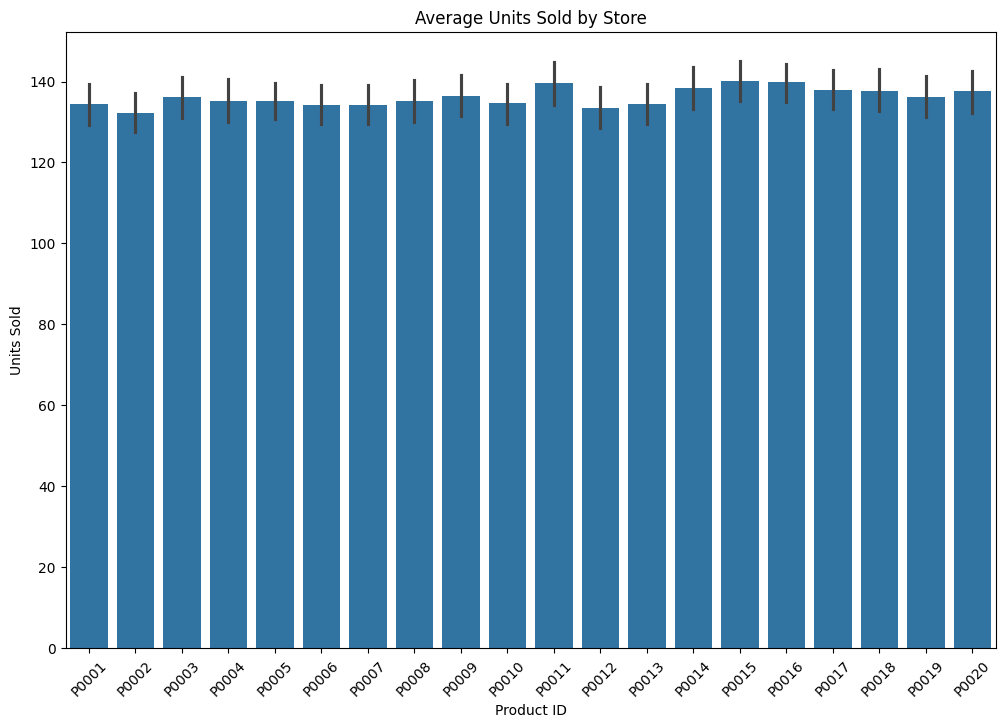

In [24]:
plt.figure(figsize=(12,8))
sns.barplot(x='Product ID', y='Units Sold', data=df, estimator='mean')
plt.title('Average Units Sold by Store')
plt.xticks(rotation=45)
plt.show()

In [25]:
# The average units sold at each store seem relatively equal. Along with the products too! Our data has 
# a roughly, good represenation of each store and product. To confirm, we will look at the store counts and products too.
# Just to really show our data is well represented which means our model will handle/predict new data accurately as well

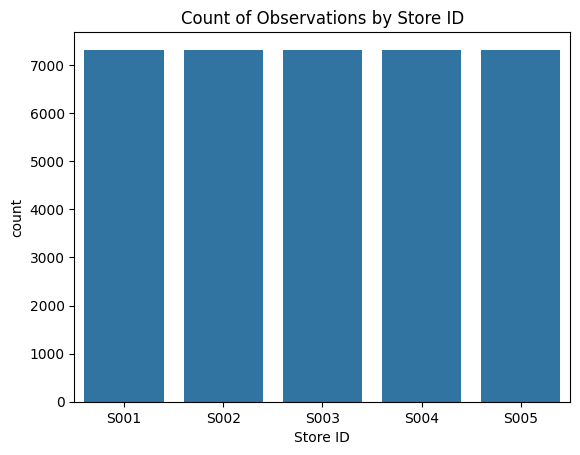

In [26]:
sns.countplot(x='Store ID', data=df)
plt.title('Count of Observations by Store ID')
plt.show()

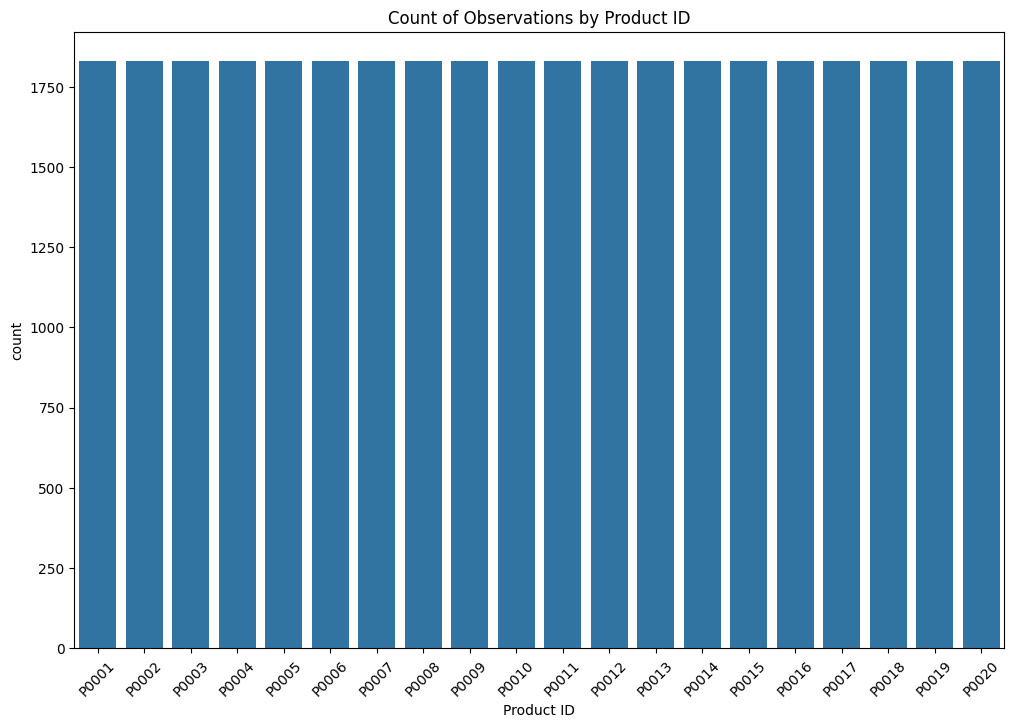

In [28]:
plt.figure(figsize=(12,8))
sns.countplot(x='Product ID', data=df)
plt.title('Count of Observations by Product ID')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Finally for visuals we will be making a correlation heat map. This will help us identify what factors have
# strong correlation to help us decided what variables we should choose for our multiple linear regression model.
# There doesn't seem to be a strong bias from either a unique store or product

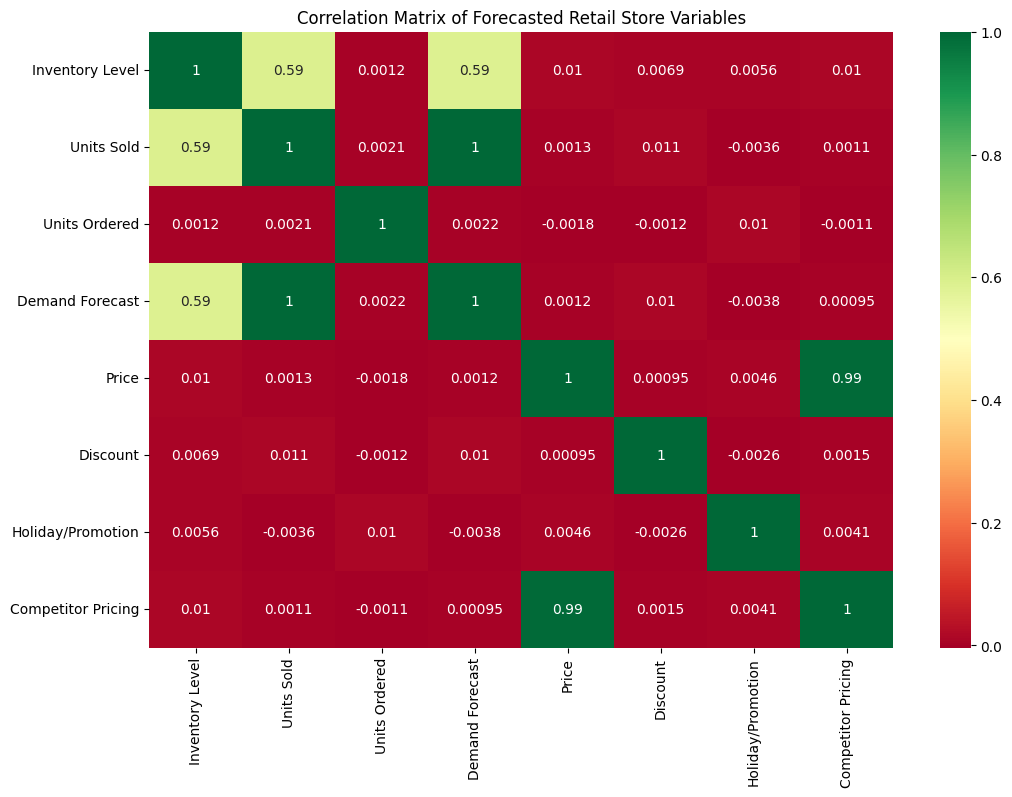

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Matrix of Forecasted Retail Store Variables')
plt.show()

In [31]:
# Our focus will be units sold. here there are a lot of red or "weak" correlations between the majority of these variables.
# While looking at units sold though, we can see the green/light green or "stronger" relationships with inventory level and demand
# forecast. With a slightly weaker relationship between units ordered and holiday/promotion.
# This is indicating that our main focuses are going to be supply vs demand. With the help of external factors like holiday/promotion, discount, 
# and units ordered, our multiple linear regression model is going to take a look at crafting the best prediction outcome based on demand 
# of the product. This will be able to help us predict how much stock to buy because we will be able to predict how many units are going to be sold.

In [ ]:
# Finally we will run a describe analysis to view the overall numerical values

In [33]:
print(df.describe())

       Inventory Level    Units Sold  Units Ordered  Demand Forecast  \
count     36600.000000  36600.000000   36600.000000     36600.000000   
mean        274.149945    136.173716     110.142678       141.208696   
std         129.958751    108.784554      52.194365       109.081550   
min          50.000000      0.000000      20.000000        -9.970000   
25%         162.000000     48.000000      65.000000        53.487500   
50%         273.000000    107.000000     110.000000       112.980000   
75%         386.000000    203.000000     155.000000       207.977500   
max         500.000000    499.000000     200.000000       518.550000   

              Price      Discount  Holiday/Promotion  Competitor Pricing  
count  36600.000000  36600.000000       36600.000000        36600.000000  
mean      54.988310     10.003279           0.495656           55.012043  
std       26.076935      7.102970           0.499988           26.259164  
min       10.000000      0.000000           0.00000

In [34]:
# These numbers prove what we saw visually in terms of outliers and the distribution of data
# Based on the mean and medians, we can see that the units ordered and discount are slightly left skewed. While the other variables are slightly
# right skewed. Units sold and demand forecast are the most skewed out of all the variables. Indicating most of our data is somewhat normally 
# distributed. The standard deviation for our numerical values are higher for demand forecast and units sold versus the other variables. 
# This explains the heavy skew that associates with demand forecast and units sold

In [35]:
# Final thoughts

In [ ]:
# Our data is well represented across all five stores and the total products that are being sold
# Taking into consideration our high skewness with demand forecast, we might need to log transform our data
# we would highly recommend we include demand forecast with our multiple linear regression though,
# as it has a high correlation and determination of units sold. On top of that, we would consider including
# inventory level, as well as holiday/promotion, discount, and units ordered. Given their slightly better correlation
# compared to the other variables. Since demand is such a crucial aspect to units sold but has a high correlated predictor,
# we will need to adjust our model to avoid multicollinearity. Finally the categorical variables, region, weather conditions, and seasonality, don't
# seem relevant. Demand of these products at all five stores still holds true regardless of region, weather, or season. There is a slight favorability
# towards the east region, sunny day, and autumn weather, but it's not enough to have an impact on units sold.